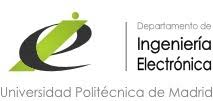

<div align="center">


# **Reconocimiento de gestos con la mano (Hand Gesture Recognition)**
### **Versión del 7 de Marzo de 2026**
---
---

</div>

In many contexts, having information about the movements of a person can be highly beneficial for diagnosing certain diseases. Parkinson's disease serves as a prime example, as it is a progressive disorder that affects the nervous system and impairs movement. In some cases, the disease initially manifests as subtle tremors that may not be visible to the naked eye but can be easily detected by an inertial sensor. To expand on the concept further, it is worth considering the utility of detecting landmarks from images and videos of individuals in real-time. Landmark detection involves identifying specific points or features of interest on a person's body, such as joints, facial landmarks, or key anatomical landmarks. These landmarks provide crucial information about the position, orientation, and movement of various body parts.  By leveraging computer vision techniques, cameras or video sensors can capture real-time images or video footage of individuals and detect the positions of these landmarks. This information can be invaluable for a wide range of applications, including  Gesture Recognition: Landmark detection enables the tracking and analysis of hand gestures or body movements. By recognizing specific patterns and trajectories of landmarks, it becomes possible to develop gesture recognition systems that can interpret and understand human movements.


1.   Biomechanical Analysis: Detecting landmarks from images or videos allows for the analysis of human biomechanics. By tracking the positions and movements of anatomical landmarks, it becomes possible to study and evaluate body mechanics, identify abnormalities, and aid in the diagnosis and treatment of musculoskeletal disorders.


2.   Physical Rehabilitation: Landmark detection can be employed in physical
rehabilitation settings to track and analyze a patient's movements during therapy sessions. By monitoring the positions and trajectories of specific landmarks, therapists can assess the progress of rehabilitation exercises and provide real-time feedback to patients.

3.  Human-Computer Interaction: By detecting landmarks, devices such as cameras or depth sensors can enable natural and intuitive interaction between humans and computers. This technology can facilitate applications like virtual reality, augmented reality, or touchless interfaces that respond to specific gestures or body movements.  To utilize landmark detection from images or video in real-time scenarios, advanced computer vision algorithms and techniques are employed.

These algorithms analyze the visual data, identify and track the desired landmarks, and extract meaningful information for further processing or application-specific tasks.


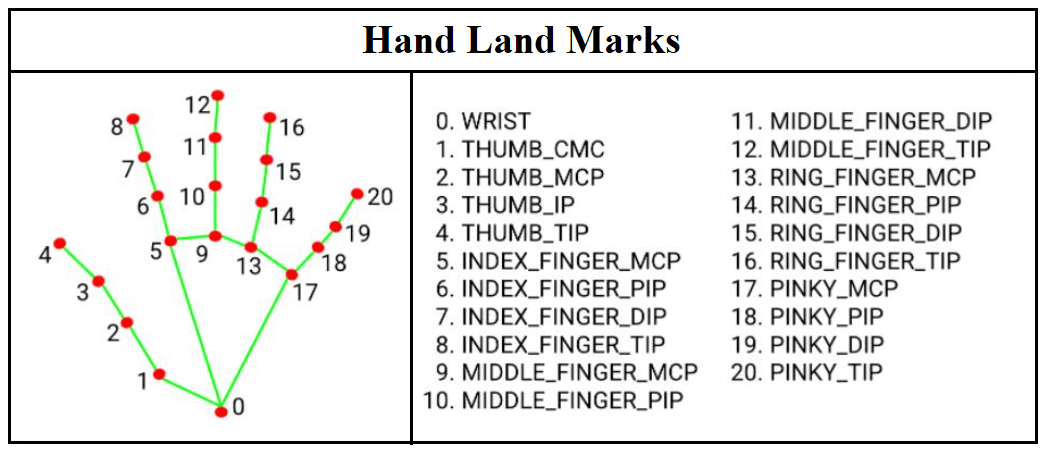






**Data Analysis**

For the purpose of our analysis, we will be working with the landmarks extracted from the images. These landmarks provide information about the position and orientation.
Our goal will be to develop models or perform analysis to discern between the different gestures based on the extracted landmarks. This could involve tasks such as gesture recognition, activity classification...


**Summary**

This practice is dedicated to the familiarization with the tools introduced during the course, more specifically, to mediapipe and Tensorflow.

The main concepts that we will work are:

1. Firstly, we will extract, interpret, and work with landmarks from different images. This involves extracting the relevant features or points of interest from the images and representing them as landmarks.
2. Secondly, we will train multiple models using the extracted landmarks. We will analyze the performance and predictions of each model, evaluating metrics such as accuracy, precision, recall, and F1-score. This step allows us to assess how well each model performs in recognizing and classifying gestures based on the landmarks
3. Thirdly, we will compare the performance of the different models and make any necessary adjustments or refinements. This may involve fine-tuning the models' hyperparameters, adding more data to improve generalization, or applying techniques to address specific challenges or limitations. The goal is to select the most suitable model that achieves the best overall performance in classifying the gestures based on the landmarks.

## Versión local (Windows + GPU NVIDIA) de este notebook

Adaptación del notebook de Colab de la asignatura para ejecutarlo **en local, en el portátil**, con las
tomas que ha grabado el grupo con el kit (`kit-grabacion`). Las celdas marcadas con `[LOCAL]` son las
que cambian; el resto es el notebook original.

| Qué | Original (Colab) | Esta versión |
|---|---|---|
| Entorno | Google Drive + `git clone` + `!pip install` | celda de configuración; **no instala nada** |
| Rutas | `/content/...`, `~/workspace/...`, relativas | absolutas a partir de la ubicación del notebook |
| Datos | una carpeta `new_dataset/` | junta las **tomas completas** de los 5 participantes en `data/gestos_pids/` |
| Motor de Keras | TensorFlow | **PyTorch** en la GPU NVIDIA (TensorFlow no usa GPU en Windows nativo y Smart App Control bloquea sus DLL en este portátil) |
| MediaPipe | la última | 0.10.35 (la 1.0.x la bloquea Smart App Control) |
| Reproducibilidad | solo `np.random.seed` | semillas de Python, NumPy y Keras |
| Celdas de CNN2 / fine-tuning | fallan si no se han entrenado | se saltan con un aviso |

**Cómo ejecutarlo:** abrir en VS Code → *Select Kernel* → *Python Environments* → `.venv` de
`PIDS_HandPose`, y *Run All*. Tarda unos minutos (la extracción de landmarks de 3000 imágenes es lo lento).

**Qué genera** (todo dentro de `HAR_mediapipe/data/gestos_pids/`):
- `train/` y `test/`: las imágenes de las tomas (enlaces, no copias) y `origen_imagenes.csv`
- `landmarks/`: **un CSV por gesto con las coordenadas (x, y) de los 21 puntos** que MediaPipe dibuja en la mano
- `annotations/`: las imágenes con los puntos dibujados
- `*_dataset_with_labels*.csv`, `*_dataset*.npy`, `results/results.txt`
- el modelo en `HAR_mediapipe/models/gestos_pids_CNN1.keras`

**Limitaciones metodológicas del notebook original** (se mantienen para no cambiar la práctica; el
pipeline de `entrenamiento/` las corrige y es el que debe usarse para las cifras de la memoria):
1. `validation_data` es el **test**, así que el test decide cuándo parar el entrenamiento.
2. `norm_type = "None"`: **no se normaliza** respecto a la muñeca.
3. La clase `NO_GESTURE` son filas de ceros idénticas en train y en test.
4. La partición train/test es **temporal dentro de cada toma**: las mismas personas están en ambos lados.

# Workspace preparation

## [LOCAL] Configuración
Sustituye al montaje de Google Drive y al `git clone` del original.

In [1]:
# ============================  [LOCAL] CONFIGURACIÓN  ============================
# Sustituye al montaje de Google Drive y al `git clone` de Colab.
import os
import sys
import random
from pathlib import Path

# Keras 3 con PyTorch como motor: es la única forma de entrenar en la GPU NVIDIA en Windows
# nativo. Tiene que fijarse ANTES de importar keras (si ya lo importaste, reinicia el kernel).
os.environ['KERAS_BACKEND'] = 'torch'
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('GLOG_minloglevel', '2')


def buscar_raiz(inicio):
    """Carpeta que contiene HAR_mediapipe/ y common/, buscando hacia arriba."""
    for p in [inicio, *inicio.parents]:
        if (p / 'HAR_mediapipe' / 'src' / 'landmarksLib.py').exists() and (p / 'common').is_dir():
            return p
    raise RuntimeError('No encuentro HAR_mediapipe/ y common/ por encima de %s' % inicio)


ROOT_DIR = buscar_raiz(Path.cwd().resolve())      # ...\PIDS_HandPose\work
PROJECT_DIR = ROOT_DIR.parent                     # ...\PIDS_HandPose

# Donde están las tomas del grupo (una carpeta gestos_<participante>_<fecha-hora> por toma).
# Solo se usan las que su metadata.json marca como 'completa'.
CARPETAS_TOMAS = [PROJECT_DIR / 'kit-grabacion' / 'HAR_mediapipe' / 'data',
                  PROJECT_DIR / 'entrenamiento' / 'datos']
DATASET_NOMBRE = 'gestos_pids'        # carpeta combinada dentro de HAR_mediapipe/data/
GUARDAR_IMAGENES_ANOTADAS = True      # como el original: guarda los JPG con los landmarks dibujados
NOMBRE_MODELO = 'gestos_pids'         # root_filename del modelo guardado
SEMILLA = 2022                        # la del notebook original

# Las funciones del repo escriben con rutas relativas ('HAR_mediapipe/logs.txt'):
os.chdir(ROOT_DIR)
for p in (ROOT_DIR / 'HAR_mediapipe' / 'src', ROOT_DIR / 'common'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

random.seed(SEMILLA)
import numpy as np
np.random.seed(SEMILLA)

# Detección de GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('AVISO: no se detecta GPU CUDA; se entrenará en CPU')
print('Carpeta de trabajo:', ROOT_DIR)

Usando: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM disponible: 8.5 GB
Carpeta de trabajo: C:\Users\Javier\PIDS_HandPose\work


## [LOCAL] Comprobación del entorno
Sustituye a la instalación de MediaPipe con `pip` (celda 7 del original).

In [2]:
# [LOCAL] Comprobación del entorno (sustituye a la instalación con pip del original: aquí no se instala nada)
import importlib
import importlib.util
import platform
import keras

print('Python', platform.python_version(), '->', sys.executable)
print('Keras ', keras.__version__, '| backend:', keras.backend.backend())
assert keras.backend.backend() == 'torch', \
    'Keras no usa PyTorch: reinicia el kernel y ejecuta primero la celda de configuración'
for m in ('torch', 'mediapipe', 'cv2', 'numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn'):
    print(f'{m:11s}', importlib.import_module(m).__version__)
if importlib.util.find_spec('tensorflow') is not None:
    print('AVISO: TensorFlow está instalado. MediaPipe intentará cargarlo y Smart App Control lo bloquea.')
else:
    print('tensorflow  no instalado (correcto: no se necesita)')

Python 3.12.9 -> C:\Users\Javier\PIDS_HandPose\.venv\Scripts\python.exe
Keras  3.15.1 | backend: torch
torch       2.10.0+cu128


mediapipe   0.10.35
cv2         5.0.0
numpy       2.5.3
pandas      3.0.5
sklearn     1.9.0
matplotlib  3.11.2
seaborn     0.13.2
tensorflow  no instalado (correcto: no se necesita)


## Import required libraries

In this section, we will download and import all the neccessary packages for running the experiments.

Among the packages and libraries installed, the most important are:

* **Mediapipe** is an open-source framework developed by Google that provides a comprehensive pipeline for building multimodal (audio, video, and sensor) applications. It offers a wide range of pre-built and customizable machine learning models and processing modules, making it easier to develop complex multimedia applications.
* **pandas**: Python library that lets deal with csv and convert them to a DataFrame, type of data organization in a kind of table format.
* **tensorflow**: Open source software library for numerical computation using data-flow graphs and for implementing and training artificial neural networks.
* **numpy**: This Python library is oriented to make numeric operactions, algebra and mathematic analysis.
* **matplotlib**: This Python library contains graphic plot functions, similr to the resources available in Matlab for showing graphs.




## Path definition and libs import checking

In [3]:
# [LOCAL] Las rutas ya se añadieron en la celda de configuración (antes: /content/IE-workspace/...)
import landmarksLib
print("Recursos de landmarksLib:", [n for n in dir(landmarksLib) if not n.startswith('_')])

import config
print("Recursos de config:", [n for n in dir(config) if not n.startswith('_')])

Recursos de landmarksLib: ['ArrangeInputDataForNetwork', 'FONT_SIZE', 'FONT_THICKNESS', 'GetLandmarksFromImages', 'GetLandmarksListFromDetectionResult', 'HANDEDNESS_TEXT_COLOR', 'MARGIN', 'create_numpy_with_feats_and_csv_with_just_labels', 'cv2', 'draw_landmarks_on_image', 'extract_classes_list_from_folders', 'get_XYZ', 'load_individual_class_features_and_create_labeled_csv_dataset', 'mp', 'mp_drawing', 'mp_drawing_styles', 'mp_hands', 'normalize_from_0_landmark', 'np', 'os', 'pd', 'remove_last_subfolder', 'sorted_lists_match']
Recursos de config: ['Config', 'ConfigMediapipeDetector', 'DEFAULT_DETECTOR_PATH', 'RecordingSetup', 'lib_path', 'mp', 'os', 'python', 'random', 'sys', 'vision', 'wait_for_keypress']


> **[LOCAL]** La sección *"ONLY WHEN EXECUTING FROM DESKTOP"* del original (instalación con `%pip` y
> `%cd ~/workspace/IE-workspace/`) queda sustituida por las celdas de configuración y comprobación del
> principio.

## Data folder specification

Links to the folder containing the database of images that will be used. **Please, note that the name of the subfolder containing the data must be updated accordingly if you wan to work with a different dataset.**

> **[LOCAL]** En vez de subir una carpeta `new_dataset` a Drive, la siguiente celda junta las tomas
> completas del grupo en `HAR_mediapipe/data/gestos_pids/` con la estructura que espera el resto del
> notebook (`train/<gesto>/*.jpg` y `test/<gesto>/*.jpg`).

In [4]:
# =====================  [LOCAL] DATASET COMBINADO A PARTIR DE LAS TOMAS  =====================
# - No copia las imágenes: crea enlaces duros de NTFS (0 bytes extra). Si no se puede, las copia.
#   AVISO CRÍTICO: Al usar enlaces duros (os.link), editar o sobrescribir imágenes en gestos_pids/
#   modifica directamente las imágenes originales de las tomas. No modificar imágenes en esta carpeta.
# - Para que los nombres no choquen, el frame pasa a  k*1000 + frame  (k = nº de toma, 1..N):
#   ok_00001.jpg de la 3ª toma -> ok_03001.jpg. La correspondencia queda en origen_imagenes.csv.
# - Se rehace en cada ejecución para recoger tomas nuevas. Solo se limpia si lleva la marca
#   .dataset_combinado, así que nunca borra una carpeta ajena.
import json
import re
import shutil
import pandas as pd

PATRON_FRAME = re.compile(r'^([a-zA-Z0-9]+)_(\d{5})\.jpg$')

def tomas_completas(carpetas):
    tomas = []
    vistas = set()
    for base in carpetas:
        if not base.exists():
            continue
        for d in sorted(base.rglob('gestos_*')):
            f_meta = d / 'metadata.json'
            if not (d / 'train').is_dir() or '_pruebas' in d.parts:
                continue
            if not f_meta.exists():
                print(f'  se ignora {d.name}: no tiene metadata.json')
                continue
            meta = json.loads(f_meta.read_text(encoding='utf-8'))
            if meta.get('estado') == 'completa' and not meta.get('prueba'):
                # Deduplicar si la misma toma aparece en más de una carpeta de búsqueda
                clave = meta.get('toma') or d.name
                if clave in vistas:
                    print(f'  se ignora duplicado: {d.name}')
                    continue
                vistas.add(clave)
                tomas.append((d, meta))
            else:
                print(f'  se ignora {d.name}: estado "{meta.get("estado")}"')
    return tomas


tomas = tomas_completas(CARPETAS_TOMAS)
if not tomas:
    raise RuntimeError('No hay ninguna toma completa en %s' % [str(c) for c in CARPETAS_TOMAS])
print(f'{len(tomas)} tomas completas:', ', '.join(f'{d.name}' for d, _ in tomas))

destino = ROOT_DIR / 'HAR_mediapipe' / 'data' / DATASET_NOMBRE
marca = destino / '.dataset_combinado'

# Limpieza segura que preserva la marca en todo momento (evita fallos si un archivo está en uso)
if destino.exists():
    if not marca.exists():
        raise RuntimeError(f'{destino} ya existe y no la creó este notebook: cambia DATASET_NOMBRE')
    for item in destino.iterdir():
        if item.name == '.dataset_combinado':
            continue
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()
else:
    destino.mkdir(parents=True, exist_ok=True)

marca.write_text('Carpeta generada por HAR_mediapipe_local.ipynb. Se puede borrar.', encoding='utf-8')

filas, copiadas = [], 0
for k, (toma, meta) in enumerate(tomas, start=1):
    for sub in ('train', 'test'):
        for d_clase in sorted(p for p in (toma / sub).iterdir() if p.is_dir()):
            clase_esperada = d_clase.name
            (destino / sub / clase_esperada).mkdir(parents=True, exist_ok=True)
            for f in sorted(d_clase.glob('*.jpg')):
                m = PATRON_FRAME.match(f.name)
                if not m:
                    print(f'  [AVISO] Archivo con nombre inesperado ignorado: {f}')
                    continue
                clase_archivo, frame_str = m.group(1), m.group(2)
                if clase_archivo != clase_esperada:
                    print(f'  [AVISO] Clase en nombre {clase_archivo} != carpeta {clase_esperada} en {f}')
                    continue
                frame = int(frame_str)
                if not (1 <= frame <= 999):
                    print(f'  [AVISO] Frame {frame} fuera de rango [1, 999] en {f}')
                    continue

                nombre = f'{clase_esperada}_{k * 1000 + frame:05d}.jpg'
                dst = destino / sub / clase_esperada / nombre

                if dst.exists():
                    raise FileExistsError(f'Conflicto de archivos: el destino ya existe: {dst}. Posible colisión de nombres.')

                try:
                    os.link(f, dst)
                except FileExistsError:
                    raise
                except OSError:
                    shutil.copy2(f, dst)
                    copiadas += 1

                filas.append({'subset': sub, 'clase': clase_esperada, 'archivo': nombre,
                              'participante': meta.get('participante'), 'mano': meta.get('mano'),
                              'toma': toma.name, 'frame_original': frame, 'ruta_original': str(f)})

origen = pd.DataFrame(filas)
origen.to_csv(destino / 'origen_imagenes.csv', index=False)
print(f'\n{len(origen)} imágenes en {destino} ({copiadas} copiadas, el resto enlazadas)')
print(origen.pivot_table(index='participante', columns=['subset', 'clase'], values='archivo', aggfunc='count'))

  se ignora gestos_p1_20260914-163103: estado "interrumpida"
  se ignora gestos_p1_20260914-163127: estado "en_curso"
  se ignora gestos_p2_20260914-163325: estado "en_curso"
  se ignora gestos_p3_20260914-163405: estado "en_curso"
5 tomas completas: gestos_p1_20260914-163555, gestos_p2_20260914-165026, gestos_p3_20260916-153029, gestos_p4_20260916-154654, gestos_p5_20260916-155908



3000 imágenes en C:\Users\Javier\PIDS_HandPose\work\HAR_mediapipe\data\gestos_pids (0 copiadas, el resto enlazadas)
subset       test                                          train             \
clase          ok paper rock rockandroll scissors thumbsup    ok paper rock   
participante                                                                  
p1             30    30   30          30       30       30    70    70   70   
p2             30    30   30          30       30       30    70    70   70   
p3             30    30   30          30       30       30    70    70   70   
p4             30    30   30          30       30       30    70    70   70   
p5             30    30   30          30       30       30    70    70   70   

subset                                      
clase        rockandroll scissors thumbsup  
participante                                
p1                    70       70       70  
p2                    70       70       70  
p3                    70 

In [5]:
# [LOCAL] Rutas absolutas (antes: r'HAR_mediapipe/' relativo o '/content/IE-workspace/HAR_mediapipe/').
# Se mantienen como texto terminado en '/' porque las funciones del repo las concatenan así.
root_path = ROOT_DIR.as_posix() + '/HAR_mediapipe/'

# Folder where the input data is saved
data_path = root_path + r'data/'
new_dataset_path = data_path + DATASET_NOMBRE + '/'   # [LOCAL] antes: 'new_dataset/'
new_dataset_annotations_path = new_dataset_path + r'annotations/'
new_dataset_landmarks_path = new_dataset_path + r'landmarks/'
dataset_path = {}
dataset_path['train'] = new_dataset_path + r'train/'
dataset_path['test'] = new_dataset_path + r'test/'

# Folder where the models are stored
models_path = root_path + r'models/'

# SUMMARY
print('data_path = ', data_path)
print('new_dataset_path = ', new_dataset_path)
print('new_dataset_annotations_path = ', new_dataset_annotations_path)
print('new_dataset_landmarks_path = ', new_dataset_landmarks_path)
print('dataset_path[train] = ', dataset_path['train'])
print('dataset_path[test] = ', dataset_path['test'])
print('models_path = ', models_path)

data_path =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/
new_dataset_path =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/
new_dataset_annotations_path =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/annotations/
new_dataset_landmarks_path =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/landmarks/
dataset_path[train] =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/train/
dataset_path[test] =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/test/
models_path =  C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/models/


# Landmark estimation and extraction

This code processes both train and test folders retrieving the images and processing them to obtain the corresponding landmarks.

In [6]:
import os
import contextlib
import time
from config import Config
from config import ConfigMediapipeDetector
from landmarksLib import GetLandmarksFromImages

detector_path = models_path + f'hand_landmarker.task'

# [LOCAL] GetLandmarksFromImages imprime 2-3 líneas por imagen (miles con 5 tomas): se mandan a
# extraccion_landmarks.log y aquí solo se muestra el resumen.
log_extraccion = new_dataset_path + 'extraccion_landmarks.log'

if __name__ == '__main__':
  config = Config(save_images=GUARDAR_IMAGENES_ANOTADAS)   # [LOCAL] el original ponía save_images=True

  # Create the detector
  detector = ConfigMediapipeDetector(detector_path)

  num_successful_detections = {}
  num_successful_detections['train'] = {}
  num_successful_detections['test'] = {}
  num_failed_detections = {}
  num_failed_detections['train'] = {}
  num_failed_detections['test'] = {}

  t0 = time.time()
  with open(log_extraccion, 'w', encoding='utf-8') as flog, contextlib.redirect_stdout(flog):
    for mode in ['train', 'test']:
      print('\n[Processing input data...][%s]' % mode)
      for images_class in sorted(os.listdir(dataset_path[mode])):
        print('\n\t[New class][%s]' % images_class) # ok

        class_folder_path = os.path.join(dataset_path[mode], images_class)
        print('\t[Folder][%s]' % class_folder_path) # ok

        IMAGE_FILES = sorted(os.listdir(class_folder_path))

        (df_successful_detections,
        num_successful_detections[mode][images_class],
        num_failed_detections[mode][images_class] ) = GetLandmarksFromImages(
            detector,
            IMAGE_FILES,
            dataset_path[mode], # Folder where the images are stored
            mode, # This is the subfolder where the images are stored (train/test)
            images_class, # This is the class of the images (e.g., 'class1', 'class2', etc.)
            new_dataset_landmarks_path, # Folder where the landmarks will be saved
            new_dataset_annotations_path, # Folder where the annotations will be saved
            config)
  print('Extracción terminada en %.0f s (detalle en %s)' % (time.time() - t0, log_extraccion))

  print('\n[SUMMARY OF SUCCESSFUL DETECTIONS]')
  num_total_ok = 0
  num_total_wrong = 0
  for mode in ['train', 'test']:
    for class_folder in sorted(os.listdir(dataset_path[mode])):
      ok = num_successful_detections[mode][class_folder]
      mal = num_failed_detections[mode][class_folder]
      num_total_ok = num_total_ok + ok
      num_total_wrong = num_total_wrong + mal
      print('\t[%s][%s][%d out of %d][%0.2f]' % (mode, class_folder, ok, ok + mal, 100 * ok / max(1, ok + mal)))

  print('[NUM TOTAL SUCCESSFUL = %d][%0.2f]' % (num_total_ok, 100*num_total_ok/max(1, num_total_ok+num_total_wrong)))
  print('[NUM TOTAL FAILED = %d][%0.2f]' % (num_total_wrong, 100*num_total_wrong/max(1, num_total_ok+num_total_wrong)))

Extracción terminada en 73 s (detalle en C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/extraccion_landmarks.log)

[SUMMARY OF SUCCESSFUL DETECTIONS]
	[train][ok][341 out of 350][97.43]
	[train][paper][344 out of 350][98.29]
	[train][rock][336 out of 350][96.00]
	[train][rockandroll][345 out of 350][98.57]
	[train][scissors][342 out of 350][97.71]
	[train][thumbsup][345 out of 350][98.57]
	[test][ok][144 out of 150][96.00]
	[test][paper][150 out of 150][100.00]
	[test][rock][139 out of 150][92.67]
	[test][rockandroll][149 out of 150][99.33]
	[test][scissors][148 out of 150][98.67]
	[test][thumbsup][148 out of 150][98.67]
[NUM TOTAL SUCCESSFUL = 2931][97.70]
[NUM TOTAL FAILED = 69][2.30]


## Data pre-processing

In summary, the code creates a CSV file with the coordinates of the landmarks. Then, it loads a CSV file with point coordinates, processes the data, and creates a new DataFrame and a numpy file that contain the transformed and labeled data for further analysis or model training.
We will have the two CSV files and the .npy file in our landmarks folder.

In [7]:
from landmarksLib import extract_classes_list_from_folders, sorted_lists_match, load_individual_class_features_and_create_labeled_csv_dataset, create_numpy_with_feats_and_csv_with_just_labels

# Make the following True if you want your model to include a NO_GESTURE class
plus_NO_GESTURE = True

# Execute once!
print("Loading data...")

classes_train = extract_classes_list_from_folders(dataset_path['train'], new_dataset_path)
classes_test = extract_classes_list_from_folders(dataset_path['test'], new_dataset_path)

print('\n[TRAIN]', classes_train)
print('[TEST]', classes_test)   # [LOCAL] el original imprimía train dos veces

if sorted_lists_match(classes_train, classes_test) == False:
  print('\n[ERROR!!!]\n[extract_classes_list_from_folders][sorted_lists_match][False]\n')
  raise RuntimeError('Las clases de train y test no coinciden')   # [LOCAL] exit() mataba el kernel

load_individual_class_features_and_create_labeled_csv_dataset('train', new_dataset_path, new_dataset_landmarks_path)
load_individual_class_features_and_create_labeled_csv_dataset('test', new_dataset_path, new_dataset_landmarks_path)

create_numpy_with_feats_and_csv_with_just_labels('train', new_dataset_path)
create_numpy_with_feats_and_csv_with_just_labels('test', new_dataset_path)

Loading data...

[extract_classes_list_from_folders][NEW .txt file]
	[C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_classes_list.txt]

[extract_classes_list_from_folders][NEW .txt file]
	[C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_classes_list.txt]

[TRAIN] ['ok', 'paper', 'rock', 'rockandroll', 'scissors', 'thumbsup']
[TEST] ['ok', 'paper', 'rock', 'rockandroll', 'scissors', 'thumbsup']

[load_individual_class_features_and_create_labeled_csv_dataset][train]
	[LOAD .txt file with the list of classes][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_classes_list.txt]
	[LOAD .csv file with landmarks][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/landmarks/train/train_ok_poses_landmarks.csv]
	[LOAD .csv file with landmarks][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids/landmarks/train/train_paper_poses_landmarks.csv]
	[LOAD .csv file with landmarks][C:/Users/Javier/PIDS_

	[NEW .csv][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_labels.csv]
	[NEW .npy][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset.npy]

[create_numpy_with_feats_and_csv_with_just_labels][test]
	[input_file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_with_labels.csv]


	[NEW .csv][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_labels.csv]
	[NEW .npy][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset.npy]


In [8]:
import pandas as pd
import numpy as np

# Number of classes
data_path = new_dataset_path
classes_list = pd.read_csv(data_path + '/' + 'train_classes_list.txt', header=None)
num_classes = len(classes_list)

print(f'\n[NUM CLASSES = {num_classes} classes]')


[NUM CLASSES = 6 classes]


## Adding *'NO_GESTURE'* extra class  (optional)

We can try reading the files that were previously generated

In [9]:
# Read csv
for input_mode in ['train', 'test']:
  filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
  df = pd.read_csv(filename)
  print('\n[Showing][%s]' % filename)
  print(df)


[Showing][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_with_labels.csv]
            x0        y0        x1        y1        x2        y2        x3  \
0     0.465484  0.527971  0.504180  0.521972  0.533909  0.500331  0.562819   
1     0.532664  0.613274  0.577987  0.619344  0.619941  0.605675  0.654148   
2     0.554230  0.636594  0.596039  0.629594  0.629309  0.611270  0.660536   
3     0.497359  0.598853  0.528174  0.611517  0.560143  0.594997  0.590082   
4     0.401307  0.638642  0.436809  0.634716  0.477497  0.608905  0.512635   
...        ...       ...       ...       ...       ...       ...       ...   
2048  0.443366  0.633657  0.418357  0.557823  0.385469  0.495378  0.364927   
2049  0.483501  0.617240  0.458441  0.542776  0.421667  0.481303  0.398319   
2050  0.356097  0.699389  0.331369  0.619218  0.287696  0.552371  0.259265   
2051  0.731993  0.587955  0.715294  0.545965  0.702274  0.488412  0.698483   
2052  0.594485  0.629587  0.56759

In [10]:
# Add as many new examples as there are examples from other classes
num_samples_per_class = df['label'].value_counts()
np.mean(num_samples_per_class)
average_num_samples_per_class = int(np.mean(num_samples_per_class))
print('num_samples_per_class')
print(num_samples_per_class)
print('average_num_samples_per_class = ', average_num_samples_per_class)

num_samples_per_class
label
2.0    150
4.0    149
5.0    148
6.0    148
1.0    144
3.0    139
Name: count, dtype: int64
average_num_samples_per_class =  146


This is where the magic actually happens

In [11]:
if plus_NO_GESTURE:
  no_gesture_class = num_classes + 1
  num_landmarks_coordinates = config.num_landmarks * 2

  for input_mode in ['train', 'test']:
    input_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels.csv'
    print('\n[LOAD .csv file][%s]' % input_filename)
    df = pd.read_csv(input_filename)

    # Add as many new examples as there are examples from other classes
    num_samples_per_class = df['label'].value_counts()
    average_num_samples_per_class = int(np.mean(num_samples_per_class))

    # Create the new row
    new_row = pd.DataFrame([[0]*num_landmarks_coordinates + [no_gesture_class] + ['NO_GESTURE'] + ['No gesture - No URL']], columns=df.columns)

    # These are for the NO GESTURE class; We add as many new rows as average_num_samples_per_class
    for i in range(average_num_samples_per_class):
        df = pd.concat([df,new_row], ignore_index=True)

    print('\t[%d NEW samples for NO GESTURE class]' % average_num_samples_per_class)

    # Save
    output_filename = new_dataset_path + '/' + input_mode + '_dataset_with_labels_plus_NO_GESTURE.csv'
    print('\n[NEW .csv file][%s]' % output_filename)
    df.to_csv(output_filename, index=False)

    # We can now reutilize 'create_numpy_with_feats_and_csv_with_just_labels'
    # to create coherent .npy and .csv files
    create_numpy_with_feats_and_csv_with_just_labels(input_mode, new_dataset_path, NO_GESTURE=True)



[LOAD .csv file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_with_labels.csv]


	[342 NEW samples for NO GESTURE class]

[NEW .csv file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_with_labels_plus_NO_GESTURE.csv]



[create_numpy_with_feats_and_csv_with_just_labels][train]
	[input_file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_with_labels_plus_NO_GESTURE.csv]


	[NEW .csv][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_labels_plus_NO_GESTURE.csv]
	[NEW .npy][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_plus_NO_GESTURE.npy]

[LOAD .csv file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_with_labels.csv]
	[146 NEW samples for NO GESTURE class]

[NEW .csv file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_with_labels_plus_NO_GESTURE.csv]

[create_numpy_with_feats_and_csv_with_just_labels][test]
	[input_file][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_with_labels_plus_NO_GESTURE.csv]


	[NEW .csv][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_labels_plus_NO_GESTURE.csv]
	[NEW .npy][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_plus_NO_GESTURE.npy]


## Csv files checking

In [12]:
if plus_NO_GESTURE:
  filename = new_dataset_path + '/' + 'test' + '_labels_plus_NO_GESTURE.csv'
  print('\n[Showing][%s]' % filename)
  df = pd.read_csv(filename)
  print(df)
else:
  filename = new_dataset_path + '/' + 'test' + '_labels.csv'
  print('\n[Showing][%s]' % filename)
  df = pd.read_csv(filename)
  print(df)


[Showing][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_labels_plus_NO_GESTURE.csv]
           frame  label
0           1071    1.0
1           1073    1.0
2           1074    1.0
3           1075    1.0
4           1076    1.0
...          ...    ...
1019  NO_GESTURE    7.0
1020  NO_GESTURE    7.0
1021  NO_GESTURE    7.0
1022  NO_GESTURE    7.0
1023  NO_GESTURE    7.0

[1024 rows x 2 columns]


## Numpy files checking

In [13]:
if plus_NO_GESTURE:
  filename = new_dataset_path + '/' + 'test' + '_dataset_plus_NO_GESTURE.npy'
  print('\n[Loading][%s]' % filename)
  data = np.load(filename)
  print(data.shape)
else:
  filename = new_dataset_path + '/' + 'test' + '_dataset.npy'
  print('\n[Loading][%s]' % filename)
  data = np.load(filename)
  print(data.shape)


[Loading][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_plus_NO_GESTURE.npy]
(1024, 42)


# Model Training

## Model definition

We will analyze the performance of four models:

*   two CNN models with a simple structure and another with a more complex structure,
*   a network using fine-tuning by leveraging the weights of the best model from the previous models,
*   and a final model using fine-tuning while freezing certain layers.

In [14]:
def DefineNetworkModel(num_classes, num_cnn_features, network_type, num_channels):
  print('\tnum_classes = %d' % num_classes)
  print('\tnum_cnn_features = %d' % num_cnn_features)
  print('\tnum_channels = %d' % num_channels)
  print('\tnetwork_type = %s' % network_type)

  if (network_type == "CNN1"):
    model = Sequential()
    # We start by adding a convolutional layer to our model
    # arg 1: Number of filters (features) that the convolutional layer will learn.
    #   Each filter extracts different features from the input.
    # arg 2: Filter size in the form (height, width). In this case, it's a filter with a height of 5 and a width of 1.
    #   The height usually captures vertical details, and the width captures horizontal details.
    # arg 3: The padding parameter controls how the image border is handled.
    #   'same' ensures that the output size is the same as the input size by padding with zeros if needed.
    # arg 4: This is the shape of the input data. num_channels refers to the number of channels
    #   (typically 1 for grayscale or 3 for RGB color images), and here it's divided by 2 to represent hand landmarks
    #   (which are stored as X and Y coordinates in a single channel).
    #   (2, 1) represents the size of the feature window (in this case, a window of 2 rows and 1 column).
    # arg 5: This specifies the activation function to use after applying the convolution.
    #   'relu' is a common activation function that sets negative values to zero and leaves positive values unchanged.
    model.add(Conv2D(num_cnn_features,
      (5, 1),
      padding='same',
      input_shape=(int(num_channels / 2), 2, 1),
      activation='relu'))

    # model.add(MaxPooling2D(pool_size=(2, 1)))
    model.add(Dropout(dropout))
    # model.add(Conv2D(num_cnn_features, (5, 1),padding='same', activation='relu'))
    # model.add(MaxPooling2D(pool_size=(2, 1)))
    # model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "CNN2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features,
      (3, 3),
      padding='same',
      input_shape=(int(num_channels / 2), 2, 1),
      activation='sigmoid'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))  # Reduce the number of units in the dense layer
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING1"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    # Carga los pesos del modelo original desde el fichero
    model.load_weights(load_model, by_name=True)
    # añadir capa final con mis clases
    model.add(Dense(num_classes, activation='softmax'))
  elif (network_type == "FINE-TUNING2"):
    model = Sequential()
    model.add(Conv2D(num_cnn_features, (5, 1), padding='same', input_shape=(int(num_channels / 2), 2, 1), activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))

    # Carga los pesos del modelo original desde el fichero
    model.load_weights(load_model, by_name=True)
    #añadir capa final con mis clases
    model.add(Dense(num_classes, activation='softmax'))

    # Congelar algunas capas
    for layer in model.layers[:3]:
        layer.trainable = False

  print('\n[MODEL SUMMARY]')
  model.summary()

  return model

## Data preparation for conventional training with train and test lists

In [15]:
import random
from landmarksLib import ArrangeInputDataForNetwork, normalize_from_0_landmark

print('\n[DATA PREPARATION]')

debug = False
norm_type = None

if plus_NO_GESTURE:
  aux = '_plus_NO_GESTURE'
else:
  aux = ''

# First we read the numpy file for train
filename = new_dataset_path + '/' + 'train' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
train_data = np.load(filename)
if debug:
  print('train_data.shape =', train_data.shape)

if norm_type == "L0":
  normalized_train_data = normalize_from_0_landmark(train_data)
  train_data = normalized_train_data

# First we read the numpy file for test
filename = new_dataset_path + '/' + 'test' + '_dataset' + aux + '.npy'
print('\t[Loading][%s]' % filename)
test_data = np.load(filename)
if debug:
  print('test_data.shape =', test_data.shape)

if norm_type == "L0":
  normalized_test_data = normalize_from_0_landmark(test_data)
  test_data = normalized_test_data

# Then we read the csv file for train
filename = new_dataset_path + '/' + 'train' + '_dataset_with_labels' + aux + '.csv'
train_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(train_new_df)

# Then we read the csv file for test
filename = new_dataset_path + '/' + 'test' + '_dataset_with_labels' + aux + '.csv'
test_new_df = pd.read_csv(filename)
print('\t[Loading][%s]' % filename)
if debug:
  print(test_new_df)

x_train_data = train_data
y_train_data = np.array(train_new_df["label"])

if debug:
  print('y_train_data (BEFORE SHUFFLING)')
  print(y_train_data)

x_test_data = test_data
y_test_data = np.array(test_new_df["label"])

if debug:
  print('y_test_data')
  print(y_test_data)

# We shuffle the training data
temp = list(zip(x_train_data, y_train_data))
random.seed(SEMILLA)   # [LOCAL] el barajado no tenía semilla
random.shuffle(temp)
res1, res2 = zip(*temp)
x_train_data, y_train_data = np.asarray(list(res1)), np.asarray(list(res2))

if debug:
  print('y_train_data (AFTER SHUFFLING)')
  print(y_train_data)

# num_classes + 1 is to include the NO GESTURE class
y_train_data_format = np.zeros((y_train_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_train_data_format.shape', y_train_data_format.shape)

y_test_data_format = np.zeros((y_test_data.shape[0], num_classes + 1), dtype=int)
if debug:
  print('y_test_data_format.shape', y_test_data_format.shape)

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

for j in range(y_train_data.shape[0]):
    y_train_data_format[j, int(y_train_data[j]) - 1] = 1

for j in range(y_test_data.shape[0]):
    y_test_data_format[j, int(y_test_data[j]) - 1] = 1

if debug:
  print('y_train_data_format')
  print(y_train_data_format)

x_train = ArrangeInputDataForNetwork (x_train_data)
x_test = ArrangeInputDataForNetwork (x_test_data)

print('[DATA PREPARATION FINISHED!!!]')


[DATA PREPARATION]
	[Loading][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_plus_NO_GESTURE.npy]
	[Loading][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_plus_NO_GESTURE.npy]
	[Loading][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//train_dataset_with_labels_plus_NO_GESTURE.csv]
	[Loading][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/gestos_pids//test_dataset_with_labels_plus_NO_GESTURE.csv]
[DATA PREPARATION FINISHED!!!]


## Common training parameters

Execute only once, do not execute with each network change!!!!!!!!

In [16]:
# Parameters
np.random.seed(2022)
num_channels = 42
batch_size = 32
epochs = 300
dropout = 0.3
num_cnn_features = 16
patience = 50 # Número de épocas sin mejora antes de detener el entrenamiento
norm_type = "None" # Current version of Mediapipe provides already normalized landmarks
#norm_type = "L0"
k = 10

# List where to save the results you want to display to compare metrics
model_results = []

## Training the model

Execute once for each change in the type of network.

#### 🔹 Optimizer Comparison in Keras

| **Optimizer** | **Recommended for** | **Suggested Initial Learning Rate** | **Usage Code** |
|--------------|---------------------|----------------------------------|--------------|
| **Adam** (🔥 Best general choice) | Complex models, large datasets, CNNs, and MLPs | `0.001` | `Adam(learning_rate=0.001)` |
| **RMSprop** | Sequential data, RNNs/LSTMs, unstable gradients | `0.0005` | `RMSprop(learning_rate=0.0005)` |
| **SGD with momentum** | Models that need better generalization | `0.01` | `SGD(learning_rate=0.01, momentum=0.9)` |
| **AdamW** | Deep networks, noisy datasets, overfitting issues | `0.001`, with `weight_decay=1e-4` | `AdamW(learning_rate=0.001, weight_decay=1e-4)` |


> **[LOCAL] Nota metodológica.** En la celda siguiente `validation_data` es el **conjunto de test**, y
> `EarlyStopping(restore_best_weights=True)` se queda con la época que mejor va en ese test. Así, el test
> interviene en el entrenamiento y la accuracy de test que sale después es optimista. Se mantiene para no
> cambiar la práctica, pero la evaluación honesta está en `entrenamiento/` (validación separada y
> participantes no vistos). Con el backend de PyTorch el entrenamiento se hace en la GPU NVIDIA.

In [17]:
import time
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, Conv3D, MaxPooling2D, MaxPooling3D, Reshape
from keras.layers import LSTM, SimpleRNN, GRU, BatchNormalization
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(SEMILLA)   # [LOCAL] reproducibilidad (el original solo fijaba numpy)
print('[LOCAL] Keras', keras.__version__, 'con backend', keras.backend.backend(), 'en', device)

print('\n[DefineNetworkModel]')

# Types: "CNN1","CNN2", "FINE-TUNING1", "FINE-TUNING2"
network_type = "CNN1"
#network_type = "CNN2"
#network_type = "FINE-TUNING1"
#network_type = "FINE-TUNING2"

# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
models_folder = data_path + '/' + 'models/'

# In case of using fine-tunning load weights of the trained model with CNN1
load_model = models_path + r'poses.h5'

# REMEMBER: num_classes + 1 is to include the NO GESTURE class
model = DefineNetworkModel(num_classes+1, num_cnn_features, network_type, num_channels)

# Definir el criterio de parada temprana
early_stopping = EarlyStopping(
    monitor='val_loss',  # Puedes cambiarlo a 'val_accuracy' si prefieres
    patience=patience,          # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True,  # Restaurar los mejores pesos del modelo
    verbose=1
)

# opt=tf.keras.optimizers.SGD(lr=0.001)
# opt=tf.keras.optimizers.RMSprop(lr=0.0005, rho=0.9, epsilon=1e-08, decay=0.0)
opt = AdamW(learning_rate=0.001, weight_decay=1e-4)  # Ajusta el weight decay según el problema
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

print('\n[model.fit][Training starts!]\n')
start_time = time.time()

# Training with Early Stopping
history = model.fit(x_train,
                    y_train_data_format,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test_data_format),  # Asegúrate de tener datos de validación
                    callbacks=[early_stopping])

[LOCAL] Keras 3.15.1 con backend torch en cuda

[DefineNetworkModel]
	num_classes = 7
	num_cnn_features = 16
	num_channels = 42
	network_type = CNN1


C:\Users\Javier\PIDS_HandPose\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[MODEL SUMMARY]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 21, 2, 16)      │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 2, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

58/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9838 - loss: 0.0565

67/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9841 - loss: 0.0613

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9846 - loss: 0.0613 - val_accuracy: 0.9600 - val_loss: 0.1831


Epoch 208: early stopping


Restoring model weights from the end of the best epoch: 158.


## Visualizing the training results

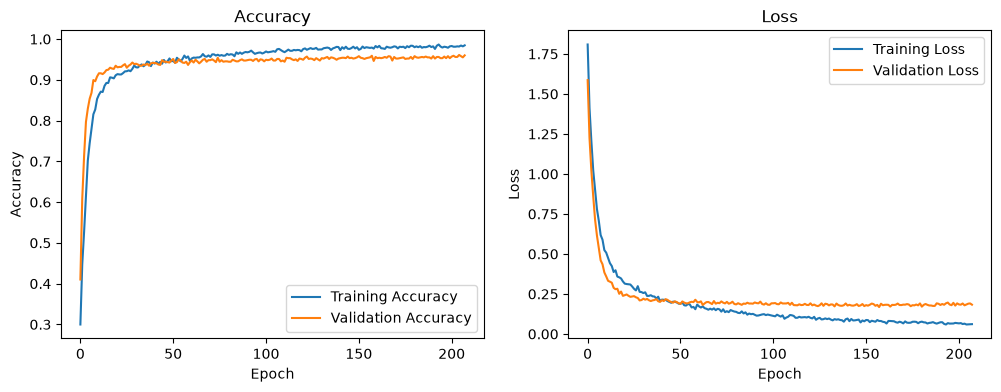

In [18]:
# prompt: plot learning curves

import matplotlib.pyplot as plt

# Assuming 'history' is the output of model.fit
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Performance analysis

In [19]:
print('\n[PERFORMANCE ANALYSIS]')
print('[SETUP]')
print('\t[Normalization: %s]' % norm_type)
print('\t[Type of network: %s]' % network_type)
print('\t[Num classes: %d]' % num_classes)

# For train data
predictions = model.predict(x_train, batch_size = batch_size, verbose = 1)
y_pred_train = np.argmax(predictions, axis=1)
y_true_train = np.argmax(y_train_data_format, axis=1)
print('y_pred_train', y_pred_train)
print('y_true_train', y_true_train)
etiquetas_clases = np.arange(num_classes + (1 if plus_NO_GESTURE else 0))   # [LOCAL]
matrix = confusion_matrix(y_true_train, y_pred_train, labels=etiquetas_clases)

print('[Number of training examples = %d]' % matrix.sum())
print('\n[Confusion matrix for training data]')
print(matrix)
print('\n[Train accuracy = %0.4f]' % accuracy_score(y_true_train, y_pred_train))
print('[Train unweighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, labels=etiquetas_clases, average='macro'))
print('[Train weighted f-measure = %0.4f]' % f1_score(y_true_train, y_pred_train, labels=etiquetas_clases, average='weighted'))

# For test data
prediction = model.predict(x = x_test, batch_size = batch_size, verbose = 1)
y_pred_test = np.argmax(prediction, axis=1)
y_true_test = np.argmax(y_test_data_format, axis=1)
print('y_pred_test', y_pred_test)
print('y_true_test', y_true_test)
matrix = confusion_matrix(y_true_test, y_pred_test, labels=etiquetas_clases)

print('[Number of test examples = %d]' % matrix.sum())
print('\n[Confusion matrix for test data]')
print(matrix)
print('\n[Test accuracy = %0.4f]' % accuracy_score(y_true_test, y_pred_test))
print('[Test unweighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, labels=etiquetas_clases, average='macro'))
print('[Test weighted f-measure = %0.4f]' % f1_score(y_true_test, y_pred_test, labels=etiquetas_clases, average='weighted'))

end_time = time.time()
execution_time = end_time - start_time

model_results.append({
    "model_type": network_type,
    "norm_type": norm_type,
    "accuracy": accuracy_score(y_true_test, y_pred_test),
    "f-measure_unweighted": f1_score(y_true_test, y_pred_test, labels=etiquetas_clases, average='macro'),
    "f-measure_weighted": f1_score(y_true_test, y_pred_test, labels=etiquetas_clases, average='weighted'),
    "execution_time": execution_time
  })


[PERFORMANCE ANALYSIS]
[SETUP]
	[Normalization: None]
	[Type of network: CNN1]
	[Num classes: 6]
 1/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

38/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


y_pred_train [3 1 3 ... 5 3 6]
y_true_train [3 1 3 ... 5 3 6]
[Number of training examples = 2395]

[Confusion matrix for training data]
[[333   5   2   0   1   0   0]
 [  1 341   1   0   1   0   0]
 [  0   1 334   0   0   1   0]
 [  1   1   2 340   1   0   0]
 [  1   0   2   0 338   1   0]
 [  0   0   0   0   0 345   0]
 [  0   0   0   0   0   0 342]]

[Train accuracy = 0.9908]
[Train unweighted f-measure = 0.9908]
[Train weighted f-measure = 0.9908]
 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


y_pred_test [0 0 0 ... 6 6 6]
y_true_test [0 0 0 ... 6 6 6]
[Number of test examples = 1024]

[Confusion matrix for test data]
[[135   6   1   0   2   0   0]
 [  3 145   1   0   1   0   0]
 [  0   2 129   0   6   2   0]
 [  1   1   1 146   0   0   0]
 [  1   0   7   1 139   0   0]
 [  0   1   4   0   0 142   1]
 [  0   0   0   0   0   0 146]]

[Test accuracy = 0.9590]
[Test unweighted f-measure = 0.9588]
[Test weighted f-measure = 0.9591]


## Model Saving
To save data in your Collab in folder 'models'.

In [20]:
# First we serialize model to JSON
model_json = model.to_json()

# Second we check whether folder for models exists or not
if not os.path.exists(models_path):
    os.makedirs(models_path)

# Third we define the root filename which will be used when creating the model files
root_filename = NOMBRE_MODELO   # [LOCAL] antes: 'new_model'

if norm_type == 'L0':
  aux = '_L0'
else:
  aux = ''

# Fourth we save the model description
json_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.json")
print(f'[SAVING MODEL DESCRIPTION][{json_filename}]')
with open(json_filename, 'w') as json_file:
    json_file.write(model_json)

# Save model using the **new recommended Keras format**
keras_filename = os.path.join(models_path, f"{root_filename}_{network_type}{aux}.keras")
print(f'[SAVING MODEL][{keras_filename}]')
model.save(keras_filename)  # ✅ Uses `.keras` format instead of `.h5`

print('[MODEL SAVED!!!]')

# [LOCAL] Lo que hay que poner en demo-custom-dataset.py para usar este modelo
# (orden alfabético y 'None' al final si se entrenó con NO_GESTURE)
clases_demo = list(classes_list[0]) + (['None'] if plus_NO_GESTURE else [])
print('\nPara demo-custom-dataset.py:')
print(f'  MODEL_PATH = PROJECT_DIR / "models" / "{os.path.basename(keras_filename)}"')
print(f'  classes = {clases_demo}')

[SAVING MODEL DESCRIPTION][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/models/gestos_pids_CNN1.json]


[SAVING MODEL][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/models/gestos_pids_CNN1.keras]
[MODEL SAVED!!!]

Para demo-custom-dataset.py:
  MODEL_PATH = PROJECT_DIR / "models" / "gestos_pids_CNN1.keras"
  classes = ['ok', 'paper', 'rock', 'rockandroll', 'scissors', 'thumbsup', 'None']


## Results saving

In [21]:
model_results

[{'model_type': 'CNN1',
  'norm_type': 'None',
  'accuracy': 0.958984375,
  'f-measure_unweighted': 0.9587547086604233,
  'f-measure_weighted': 0.959109346178627,
  'execution_time': 87.86484408378601}]

In [22]:
# Everything is referred to 'data_path' which was originally set to 'new_dataset_path'
# [LOCAL] Guardar resultados fuera de gestos_pids para no perderlos al regenerar dataset
results_folder = root_path + 'data/resultados_notebook/'

# Second we check whether folder for models exists or not
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

filename = results_folder + '/results.txt'
print('[SAVING RESULTS][%s]' % filename)

# To execute after training the 4 models.
with open(filename, 'a') as f:
    f.write(f"Model Type: {network_type}\n")
    f.write(f"Normalization Type: {norm_type}\n")
    f.write(f"Accuracy: {model_results[-1]['accuracy']}\n")
    f.write(f"F-measure (Unweighted): {model_results[-1]['f-measure_unweighted']}\n")
    f.write(f"F-measure (Weighted): {model_results[-1]['f-measure_weighted']}\n")
    f.write(f"Execution Time: {model_results[-1]['execution_time']} seconds\n")
    f.write("\n")

[SAVING RESULTS][C:/Users/Javier/PIDS_HandPose/work/HAR_mediapipe/data/resultados_notebook//results.txt]


# Systems Comparison


In this last section, we will compare results obtained from our trained models.


Comparing models is a common practice in the field of machine learning and data science to determine which model provides the best performance for a particular problem. When comparing models, the goal is to identify which one is capable of making more accurate and generalizable predictions.

When comparing models, it is important to consider the number of samples you are working with. The sample size can have a significant impact on the performance of the models and the reliability of the evaluation metrics. Depending on whether you have used cross-validation or split the data into train and test sets.

**TO DO:**
Modify the accuracy values in the cell below with the accuracy reached by your models and comment the results.
You will use either the total number of data or the number of test data when indicating the variable "num_sample_test".

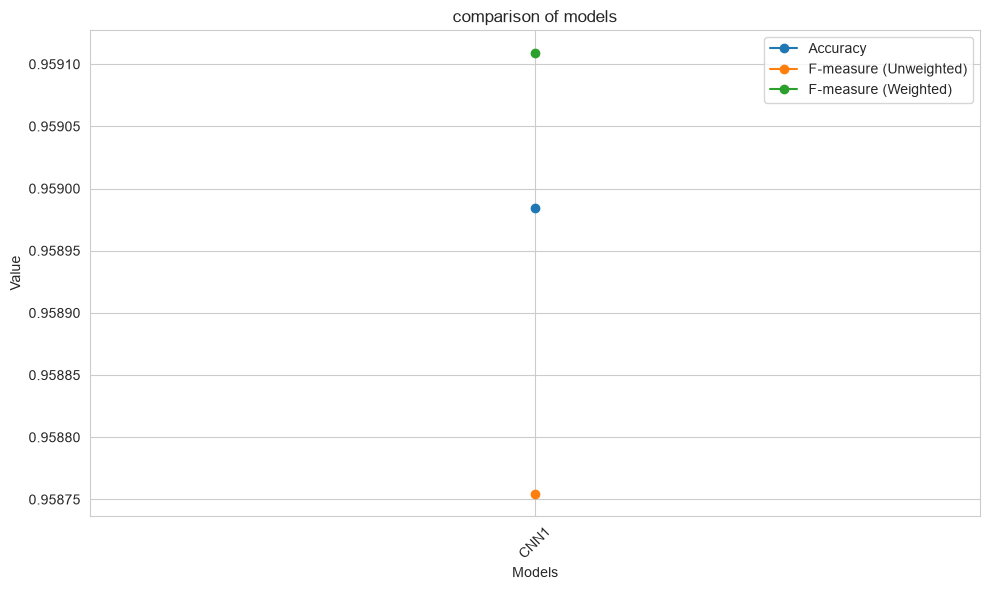

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  # Seaborn way of setting style

# Compare accuracy and f-score
model_types = [result['model_type'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
fmeasure_unweighted = [result['f-measure_unweighted'] for result in model_results]
fmeasure_weighted = [result['f-measure_weighted'] for result in model_results]

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(model_types))

# Accuracy (accuracy)
ax.plot(x, accuracies, marker='o', label='Accuracy')

# F-score  (unweighted fmeasure)
ax.plot(x, fmeasure_unweighted, marker='o', label='F-measure (Unweighted)')

# F-score  (weighted fmeasure)
ax.plot(x, fmeasure_weighted, marker='o', label='F-measure (Weighted)')

ax.set_xticks(x)
ax.set_xticklabels(model_types, rotation=45)

ax.set_title('comparison of models')
ax.set_xlabel('Models')
ax.set_ylabel('Value')

ax.legend()
plt.tight_layout()
plt.show()


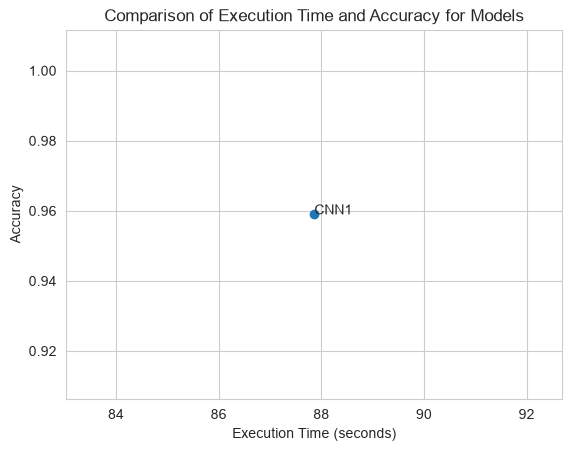

In [24]:
import matplotlib.pyplot as plt

execution_times = [result['execution_time'] for result in model_results]
accuracies = [result['accuracy'] for result in model_results]
model_types = [result['model_type'] for result in model_results]

# Create scatter plot
plt.scatter(execution_times, accuracies)

# Label each point with the model type
for i, model_type in enumerate(model_types):
    plt.annotate(model_type, (execution_times[i], accuracies[i]))

# Axis labels
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Accuracy')

# Plot title
plt.title('Comparison of Execution Time and Accuracy for Models')

# Show the plot
plt.show()

In [25]:
model_results

[{'model_type': 'CNN1',
  'norm_type': 'None',
  'accuracy': 0.958984375,
  'f-measure_unweighted': 0.9587547086604233,
  'f-measure_weighted': 0.959109346178627,
  'execution_time': 87.86484408378601}]

In [26]:
# USING CONFIDENCE INTERVALS
from evaluation import CalculateCI, find_best_result

num_samples = test_data.shape[0]

"""
num_samples is the amount of test data if we use split into  train - test and
we use the total amount of data if we use cross validation
"""

model_type_to_search = 'CNN1'
best_index = find_best_result(model_type_to_search, model_results)
assert best_index is not None, 'Entrena primero CNN1 (network_type = "CNN1")'   # [LOCAL]

if best_index is not None:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
else:
    print(f"No results found for model type '{model_type_to_search}'.")

acc_cnn1 = 100*model_results[best_index]['accuracy']
CI_cnn1 = CalculateCI(num_samples, acc_cnn1)
print('[CNN1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn1, acc_cnn1-CI_cnn1, acc_cnn1+CI_cnn1))

The best result for model type 'CNN1' is at index 0.
{'model_type': 'CNN1', 'norm_type': 'None', 'accuracy': 0.958984375, 'f-measure_unweighted': 0.9587547086604233, 'f-measure_weighted': 0.959109346178627, 'execution_time': 87.86484408378601}
[CNN1][accuracy = 95.90 (94.68, 97.11)]


### Run only when evaluating with the CNN2 option

In [27]:
# [LOCAL] Si no se ha entrenado esta red, se avisa y se sigue (el original daba error)
model_type_to_search = 'CNN2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is None:
    print(f"No hay resultados de '{model_type_to_search}': esta celda solo aplica si has entrenado esa red. Se omite.")
else:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
    acc_cnn2 = 100*model_results[best_index]['accuracy']
    CI_cnn2 = CalculateCI(num_samples, acc_cnn2)
    print('[CNN2][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_cnn2, acc_cnn2-CI_cnn2, acc_cnn2+CI_cnn2))

No hay resultados de 'CNN2': esta celda solo aplica si has entrenado esa red. Se omite.


### Run only when evaluating with the FINE-TUNNING1 option

In [28]:
# [LOCAL] Si no se ha entrenado esta red, se avisa y se sigue (el original daba error)
model_type_to_search = 'FINE-TUNING1'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is None:
    print(f"No hay resultados de '{model_type_to_search}': esta celda solo aplica si has entrenado esa red. Se omite.")
else:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
    acc_fine_tunning1 = 100*model_results[best_index]['accuracy']
    CI_fine_tunning1 = CalculateCI(num_samples, acc_fine_tunning1)
    print('[FINE-TUNING1][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning1, acc_fine_tunning1-CI_fine_tunning1, acc_fine_tunning1+CI_fine_tunning1))

No hay resultados de 'FINE-TUNING1': esta celda solo aplica si has entrenado esa red. Se omite.


### Run only when evaluating with the FINE-TUNNING2 option

In [29]:
# [LOCAL] Si no se ha entrenado esta red, se avisa y se sigue (el original daba error)
model_type_to_search = 'FINE-TUNING2'
best_index = find_best_result(model_type_to_search, model_results)

if best_index is None:
    print(f"No hay resultados de '{model_type_to_search}': esta celda solo aplica si has entrenado esa red. Se omite.")
else:
    print(f"The best result for model type '{model_type_to_search}' is at index {best_index}.")
    print(model_results[best_index])
    acc_fine_tunning2 = 100*model_results[best_index]['accuracy']
    CI_fine_tunning2 = CalculateCI(num_samples, acc_fine_tunning2)
    print('[FINE-TUNING2][accuracy = %0.2f (%0.2f, %0.2f)]' % (acc_fine_tunning2, acc_fine_tunning2-CI_fine_tunning2, acc_fine_tunning2+CI_fine_tunning2))

No hay resultados de 'FINE-TUNING2': esta celda solo aplica si has entrenado esa red. Se omite.


## Final plot

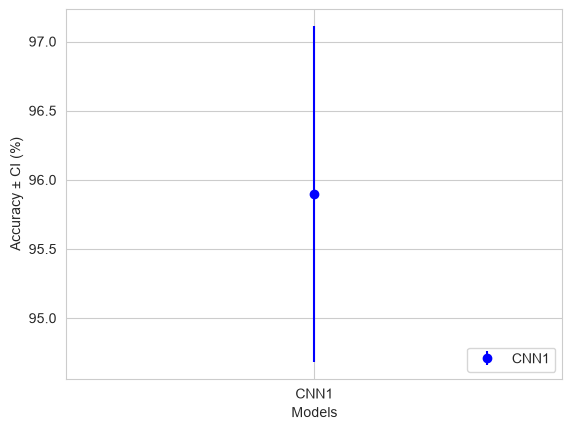

In [30]:
# PLOT RESULTS
import matplotlib.pyplot as plt
import numpy as np

# ARRAYS/INFO TO PLOT
means = [acc_cnn1]
CI = [CI_cnn1]
model_labels = ['CNN1']

# WITH FINETUNED MODELS
#means = [acc_cnn1, acc_cnn2, acc_fine_tunning1, acc_fine_tunning2]
#CI = [CI_cnn1, CI_cnn2, CI_fine_tunning1, CI_fine_tunning2]
#model_labels = ['CNN1', 'CNN2', 'FINE-TUNING1', 'FINE-TUNING2']


# PLOT DATA
fig, ax = plt.subplots(1)
plt.errorbar([0], [acc_cnn1], yerr=[CI_cnn1], fmt='o', label='CNN1', color="blue")
#plt.errorbar([1], [acc_cnn2], yerr=[CI_cnn2], fmt='o', label='CNN2', color="red")
#plt.errorbar([2], [acc_fine_tunning1], yerr=[CI_fine_tunning1], fmt='o', label='FINE-TUNNING1', color="green")
#plt.errorbar([3], [acc_fine_tunning2], yerr=[CI_fine_tunning2], fmt='o', label='FINE-TUNNING2', color="yellow")

#PLOT FORMAT
#plt.xlim(-0.5, 3.5)
plt.legend(loc='lower right')
plt.ylabel('Accuracy ± CI (%)')
plt.xlabel('Models')
plt.xticks(range(len(model_labels)), model_labels)

plt.show()